# 5. Tidal Heating Basics

A world with non-zero eccentricity or obliquity, or with non-synchronous rotation, is flexed by its host's gravity. Internal friction from that flexing dissipates orbital and rotational energy as heat. To compute it, attach a tide model to a world and call `calc_tides` with the orbital and spin state.

The constant phase lag (fixed-Q) model describes the tidal response with a Love number $k$ and a fixed lag set by a quality factor $Q$. It is analytic and needs no interior detail. This notebook applies it to Io, sweeps the heating against eccentricity and $Q$, and compares the eccentricity tide with the tides of non-synchronous rotation and obliquity. Interior rheology, which makes $k$ and the lag frequency dependent, is covered in notebook 6.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.Structures import System, build_world, make_tide

# The bundled Io and a simple Jupiter as its tidal host
io = build_world("io")
jupiter = build_world("jupiter_simple")

jovian = System("Jovian")
jovian.add_world(jupiter)
# Io's present orbit; synchronous=True sets Io's spin to its mean motion
jovian.add_world(io, tidal_host=jupiter, semi_major_axis=4.217e8, eccentricity=0.0041, synchronous=True)

n = jovian.calc_orbital_frequency(io)
print(f"Io mean motion: {n:.4e} rad/s (period {2.0 * np.pi / n / 86400.0:.3f} days)")
print(f"Io spin: {io.spin_frequency:.4e} rad/s")

Io mean motion: 4.1101e-05 rad/s (period 1.769 days)
Io spin: 4.1101e-05 rad/s


## Attaching a Fixed-Q Tide

The bundled Io carries a layered interior and a tide model built on its rheology (notebook 14). Here that tide model is replaced with a fixed-Q one, which does not use the interior. Build it with a Love number $k_2$ and quality factor $Q$, attach it, set the tidal harmonic configuration, and call `calc_tides`. The $k$ and $Q$ values are lists over harmonic degree $l$, starting at `min_degree_l` (here $l = 2$). The model's dissipation is $-\mathrm{Im}(k_2) = k_2 / Q$.

Inside a `System`, `calc_tides()` takes the orbit and spin from the system, and an argument passed to it changes that one value for the call.

In [2]:
io.set_tide_model(make_tide("fixed_q", fixed_k=[0.3], fixed_q=[100.0]))  # one value per degree l
# Truncation level N keeps all heating terms through e^N (and through I^N for obliquity).
# The classic tidal heating equation uses eccentricity_truncation=2 and obliquity_truncation=0 (off).
io.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=2, obliquity_truncation=0)

result = io.calc_tides()  # orbit and spin from the system
print(f"total tidal heating: {result['tidal_heating']:.3e} W")
print(f"surface heat flux: {io.get_tidal_heat_flux():.2f} W/m^2")

total tidal heating: 1.866e+13 W
surface heat flux: 0.45 W/m^2


Io's observed heat output is about $10^{14}$ W, or roughly 2 W/m$^2$. With $k_2 / Q = 0.003$ this model gives a fifth of that. Fitting Io's orbital motion to astrometric observations gives $k_2 / Q = 0.015 \pm 0.003$ (Lainey et al. 2009), five times larger, which reaches the observed output (see the $Q$ sweep below).

## Dependence on Eccentricity

Tidal heating is driven by the changing distance and angular velocity over an eccentric orbit. To leading order it scales as $e^2$. The sweep compares the classic $e^2$ truncation, the $e^{20}$ truncation, and the `"exact"` eccentricity functions, computed from the exact Kepler orbit and valid at any eccentricity. The truncated series fall below the exact result at large eccentricity: for this synchronous Io the $e^2$ truncation is 10 percent low past an eccentricity of about 0.12 and the $e^{20}$ truncation past about 0.69. TidalPy warns once when a truncation level is used past its range (the message below the figure), which it sets for the least favorable spin rate and tide model. Higher truncations are slower to calculate. `temporary_tide_config` changes the truncation inside its block and restores it afterwards. Notebook 17 covers the truncation levels in depth.

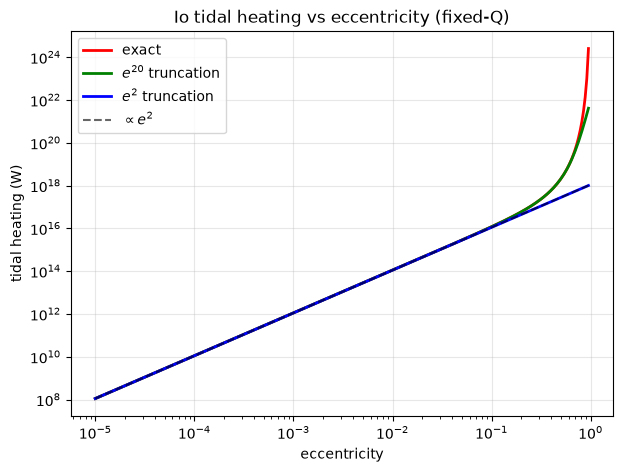

[TidalPy] [warning] TidalPy: world 'Io' has an eccentricity of 0.07568, past 0.075, where its eccentricity truncation (level 2) can misstate the tides by 10% or more (far past it, the heating can come out negative). Raise the eccentricity truncation in its [tides] table or set_tide_config (recommend_eccentricity_truncation picks a level for a tolerance); past about 0.57 use 'exact'. Shown once per level.
[TidalPy] [warning] TidalPy: world 'Io' has an eccentricity of 0.5145, past 0.5, where its eccentricity truncation (level 20) can misstate the tides by 10% or more (far past it, the heating can come out negative). Raise the eccentricity truncation in its [tides] table or set_tide_config (recommend_eccentricity_truncation picks a level for a tolerance); past about 0.57 use 'exact'. Shown once per level.


In [3]:
eccentricities = np.logspace(-5, np.log10(0.95), 300)

heating_by_level = {}
for level in (2, 20, "exact"):
    with io.temporary_tide_config(eccentricity_truncation=level):
        heating_by_level[level] = np.array([io.calc_tides(eccentricity=e)["tidal_heating"] for e in eccentricities])

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(eccentricities, heating_by_level["exact"], lw=2, c="r", label="exact")
ax.loglog(eccentricities, heating_by_level[20], lw=2, c="g", label="$e^{20}$ truncation")
ax.loglog(eccentricities, heating_by_level[2], lw=2, c="b", label="$e^{2}$ truncation")
e_squared_line = heating_by_level[2][0] * (eccentricities / eccentricities[0])**2
ax.loglog(eccentricities, e_squared_line, "k--", alpha=0.6, label=r"$\propto e^2$")
ax.set_xlabel("eccentricity")
ax.set_ylabel("tidal heating (W)")
ax.set_title("Io tidal heating vs eccentricity (fixed-Q)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

run_time = False
if run_time:
    for level in (2, 20, "exact"):
        with io.temporary_tide_config(eccentricity_truncation=level):
            print(f"Time for one tidal solve at Io's eccentricity, truncation {level}:")
            %timeit io.calc_tides()

## Other Tidal Drivers

Eccentricity is one of three drivers. A world that does not rotate synchronously is forced at twice its spin relative to the orbit, $2 (\Omega - n)$, even on a circular orbit, and a world with an obliquity is forced as the host moves above and below its equator. The cell below compares Io's present eccentricity tide with a spin of $1.5\,n$ at the same eccentricity, and with an obliquity of 1 degree on a circular orbit (obliquity truncation 2, keeping terms through $I^2$).

In [4]:
eccentricity_heating = io.calc_tides()["tidal_heating"]
spin_heating = io.calc_tides(spin_frequency=1.5 * n)["tidal_heating"]
with io.temporary_tide_config(obliquity_truncation=2):
    obliquity_heating = io.calc_tides(eccentricity=0.0, obliquity=np.radians(1.0))["tidal_heating"]

cases = [
    ("synchronous, e = 0.0041", eccentricity_heating),
    ("spin 1.5 n, e = 0.0041", spin_heating),
    ("synchronous, e = 0, obliquity 1 deg", obliquity_heating),
]
for label, case_heating in cases:
    print(f"{label:36} {case_heating:.3e} W ({case_heating / eccentricity_heating:.3g} x)")

synchronous, e = 0.0041              1.866e+13 W (1 x)
spin 1.5 n, e = 0.0041               7.927e+16 W (4.25e+03 x)
synchronous, e = 0, obliquity 1 deg  4.830e+13 W (2.59 x)


The non-synchronous spin heats Io about 4000 times more than its eccentricity does, since that tide is not reduced by a small eccentricity. Such a large dissipation slows a moon's spin toward synchronous rotation, which is why most large moons, Io among them, rotate synchronously. An obliquity of 1 degree heats Io about 2.6 times as much as its present eccentricity. To leading order the obliquity tide scales as $\sin^2 I$, as the eccentricity tide scales as $e^2$.

## Dependence on the Quality Factor

The quality factor $Q$ measures how lossy the body is. The heating is proportional to $k_2 / Q$, so a smaller $Q$ means more dissipation per cycle. The sweep below holds $k_2 = 0.3$ at Io's present eccentricity. The dotted lines mark Io's observed output of about $10^{14}$ W and $Q = 20$, which gives the $k_2 / Q = 0.015$ fitted by Lainey et al. (2009).

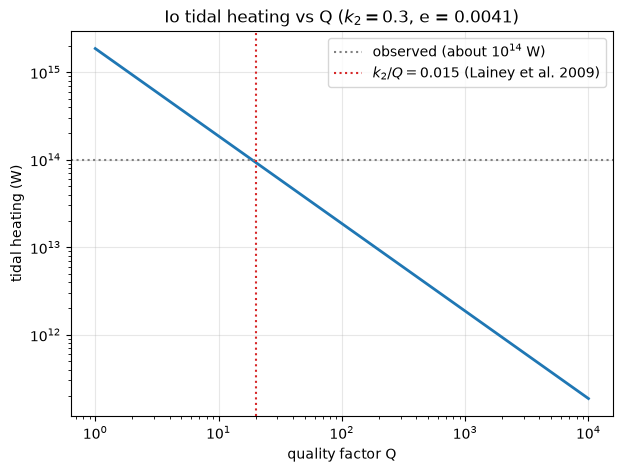

In [5]:
q_values = np.logspace(0.0, 4.0, 50)
heating_by_q = []
for q in q_values:
    io.set_tide_model(make_tide("fixed_q", fixed_k=[0.3], fixed_q=[q]))
    heating_by_q.append(io.calc_tides()["tidal_heating"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(q_values, heating_by_q, lw=2)
ax.axhline(1.0e14, color="gray", ls=":", label="observed (about $10^{14}$ W)")
ax.axvline(20.0, color="tab:red", ls=":", label="$k_2 / Q = 0.015$ (Lainey et al. 2009)")
ax.set_xlabel("quality factor Q")
ax.set_ylabel("tidal heating (W)")
ax.set_title("Io tidal heating vs Q ($k_2 = 0.3$, e = 0.0041)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()